# 02 - Open-Play Turnover Detection & Counterpress Episode Extraction

**Project**: *"When Does the Counterpress Work? Spatial Predictors of Possession Regain and Transition Risk in Elite Soccer"*  
**Target Conferences**: MIT Sloan Sports Analytics Conference (SSAC) & Carnegie Mellon Sports Analytics Conference (CMSAC)  
**Research Unit of Analysis**: **Counterpress Episode** (aggregated post-turnover sequence)  

---

## Executive Summary & Methodological Rationale
In Iteration 1, we audited action-level `counterpress=True` records. However, treating every individual pressing action as an independent event introduces severe pseudo-replication: over 38% of counterpressing situations involve multiple chained actions (pressures, tackles, blocks) within the same opposition possession.

In this notebook, we establish:
1. **The Counterpress Episode**: One episode per relevant post-turnover possession, initiated by the chronologically first valid counterpressing action.
2. **Outcome 1 (Possession Regain)**: Established possession regained within 5.0 seconds of initiation (with 3.0s and 8.0s sensitivity horizons), evaluated using StatsBomb `possession_team` semantics.
3. **Outcome 2 (Dangerous Opponent Escape)**: Opponent shot or attacking final-third penetration ($x \ge 80.0$) within 15.0 seconds before regain, conditional on not starting in that third.
4. **Three-Class Tactical Outcome**: `successful_regain`, `harmless_escape`, `dangerous_escape`.
5. **360 Eligibility & Missingness Analysis**: Comparing observable characteristics between episodes with vs. without initiation 360.
6. **100-Episode Stratified Validation**: Systematic validation protocol.


In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from counterpress.config import RAW_DIR, TABLES_DIR, RESULTS_DIR

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 150


## 1. Episode Dataset & Competition Overview

We load the extracted episodes dataset across all 424 eligible matches.


In [2]:
df_summary = pd.read_csv(TABLES_DIR / "episode_summary_by_competition.csv")
display(df_summary)


,competition,match_count,total_actions,total_episodes,open_play_episodes,pct_open_play,episodes_with_initiation_360,pct_with_360,regain_5s_count,regain_5s_pct,dangerous_escape_count,dangerous_escape_pct
0,UEFA Euro,102,9822,6305,5308,84.19,5603,88.87,3156,50.06,1019,16.16
1,Women's World Cup,64,8215,5099,4039,79.21,4641,91.02,2472,48.48,918,18.00
2,UEFA Women's Euro,61,7326,4660,3819,81.95,4200,90.13,2319,49.76,703,15.09
3,Ligue 1,58,6255,4122,3613,87.65,3523,85.47,2162,52.45,643,15.60
4,FIFA World Cup,64,6047,3964,3237,81.66,3532,89.10,2027,51.14,669,16.88
5,La Liga,35,3549,2341,2021,86.33,2218,94.75,1135,48.48,424,18.11
6,1. Bundesliga,34,3554,2293,1969,85.87,1937,84.47,1133,49.41,386,16.83
7,Major League Soccer,6,621,402,349,86.82,192,47.76,194,48.26,73,18.16
8,TOTAL,424,45389,29186,24355,83.45,25846,88.56,14598,50.02,4835,16.57


In [3]:
df_episodes = pd.read_csv(TABLES_DIR / "counterpress_episodes.csv", low_memory=False)

total_actions = df_episodes['num_counterpress_actions'].sum()
total_episodes = len(df_episodes)
ratio = total_actions / total_episodes

print(f"Total Action-Level Counterpress Records: {total_actions:,}")
print(f"Total Derived Counterpress Episodes: {total_episodes:,}")
print(f"Mean Actions per Episode: {ratio:.3f}")
print(f"Episodes in Open Play: {df_episodes['is_open_play'].sum():,} ({df_episodes['is_open_play'].mean()*100:.2f}%)")
print(f"Episodes with Initiation 360: {df_episodes['has_initiation_360'].sum():,} ({df_episodes['has_initiation_360'].mean()*100:.2f}%)")


Total Action-Level Counterpress Records: 45,389
Total Derived Counterpress Episodes: 29,186
Mean Actions per Episode: 1.555
Episodes in Open Play: 24,355 (83.45%)
Episodes with Initiation 360: 25,846 (88.56%)


## 2. Initiation Timing & Sequence Structure

We inspect the elapsed latency between the open-play turnover and the first counterpress action, and the distribution of actions per episode.


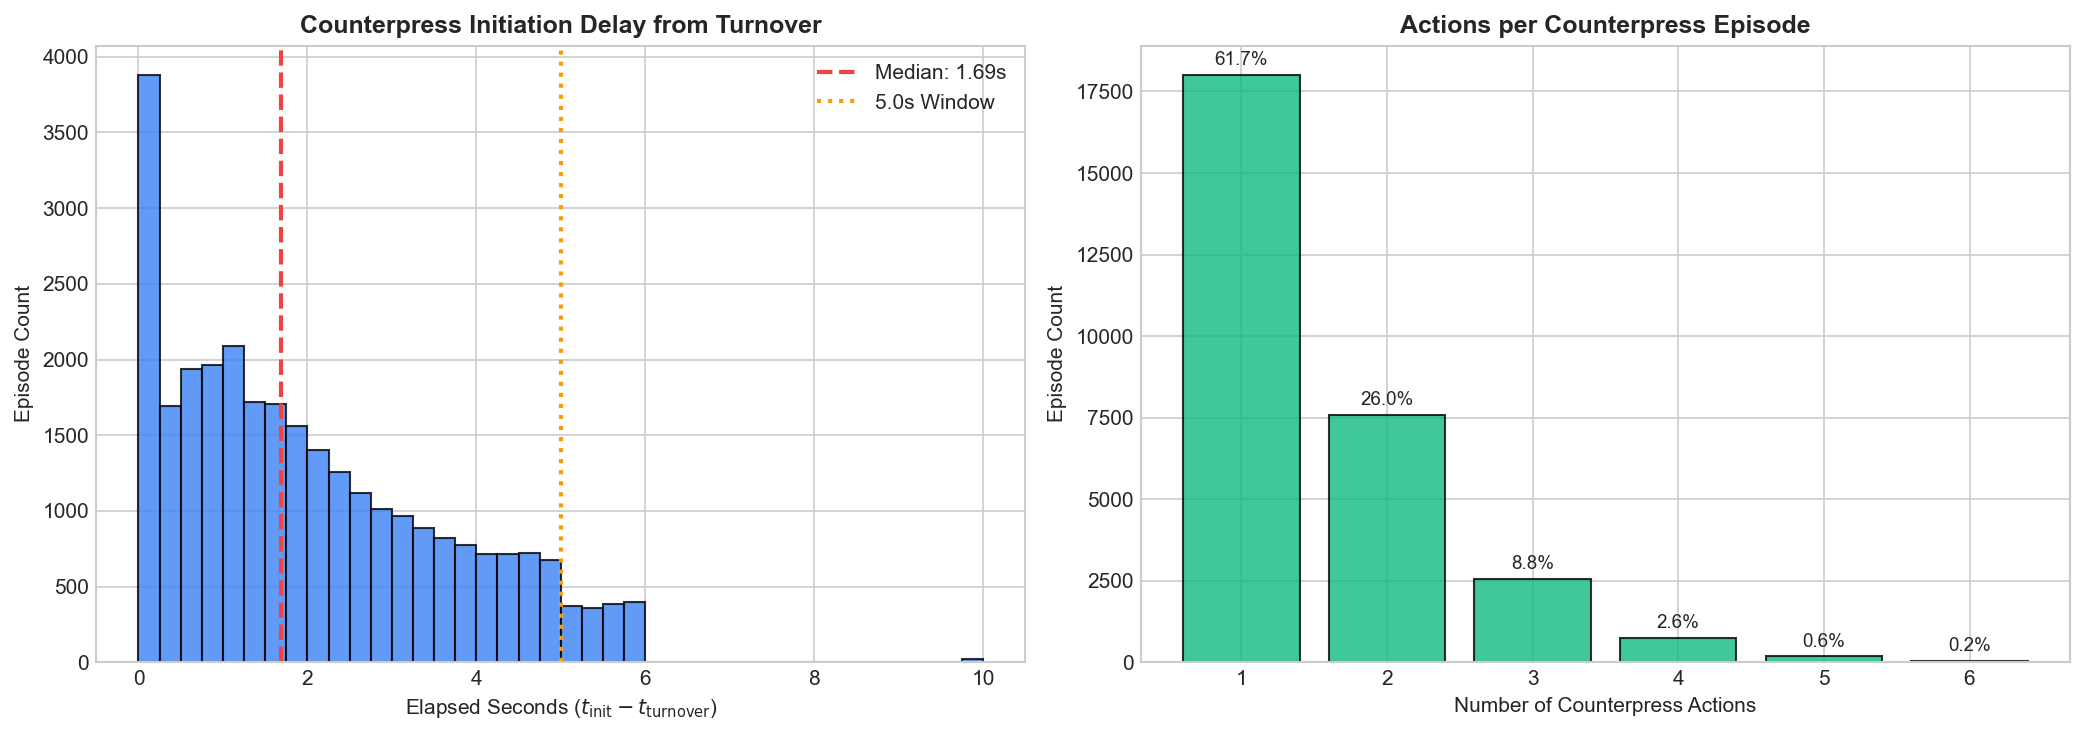

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay distribution
delays = df_episodes["delay_seconds"].clip(upper=10.0)
axes[0].hist(delays, bins=40, color="#3b82f6", edgecolor="black", alpha=0.8)
axes[0].axvline(delays.median(), color="#ef4444", linestyle="--", linewidth=2, label=f"Median: {delays.median():.2f}s")
axes[0].axvline(5.0, color="#f59e0b", linestyle=":", linewidth=2, label="5.0s Window")
axes[0].set_title("Counterpress Initiation Delay from Turnover", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Elapsed Seconds ($t_{\\rm init} - t_{\\rm turnover}$)")
axes[0].set_ylabel("Episode Count")
axes[0].legend()

# Actions per episode
action_counts = df_episodes["num_counterpress_actions"].value_counts().sort_index().head(6)
axes[1].bar(action_counts.index, action_counts.values, color="#10b981", edgecolor="black", alpha=0.8)
for x, y in zip(action_counts.index, action_counts.values):
    pct = y / total_episodes * 100
    axes[1].text(x, y + 300, f"{pct:.1f}%", ha="center", fontsize=9)
axes[1].set_title("Actions per Counterpress Episode", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Counterpress Actions")
axes[1].set_ylabel("Episode Count")

plt.tight_layout()
plt.show()


## 3. Short-Horizon Tactical Outcomes

We evaluate:
1. **Regain Horizons**: 3s, 5s (primary), and 8s.
2. **Transition Risk (15s)**: Shots and Final-Third Entries.
3. **Three-Class Tactical Distribution**: `successful_regain`, `harmless_escape`, `dangerous_escape`.


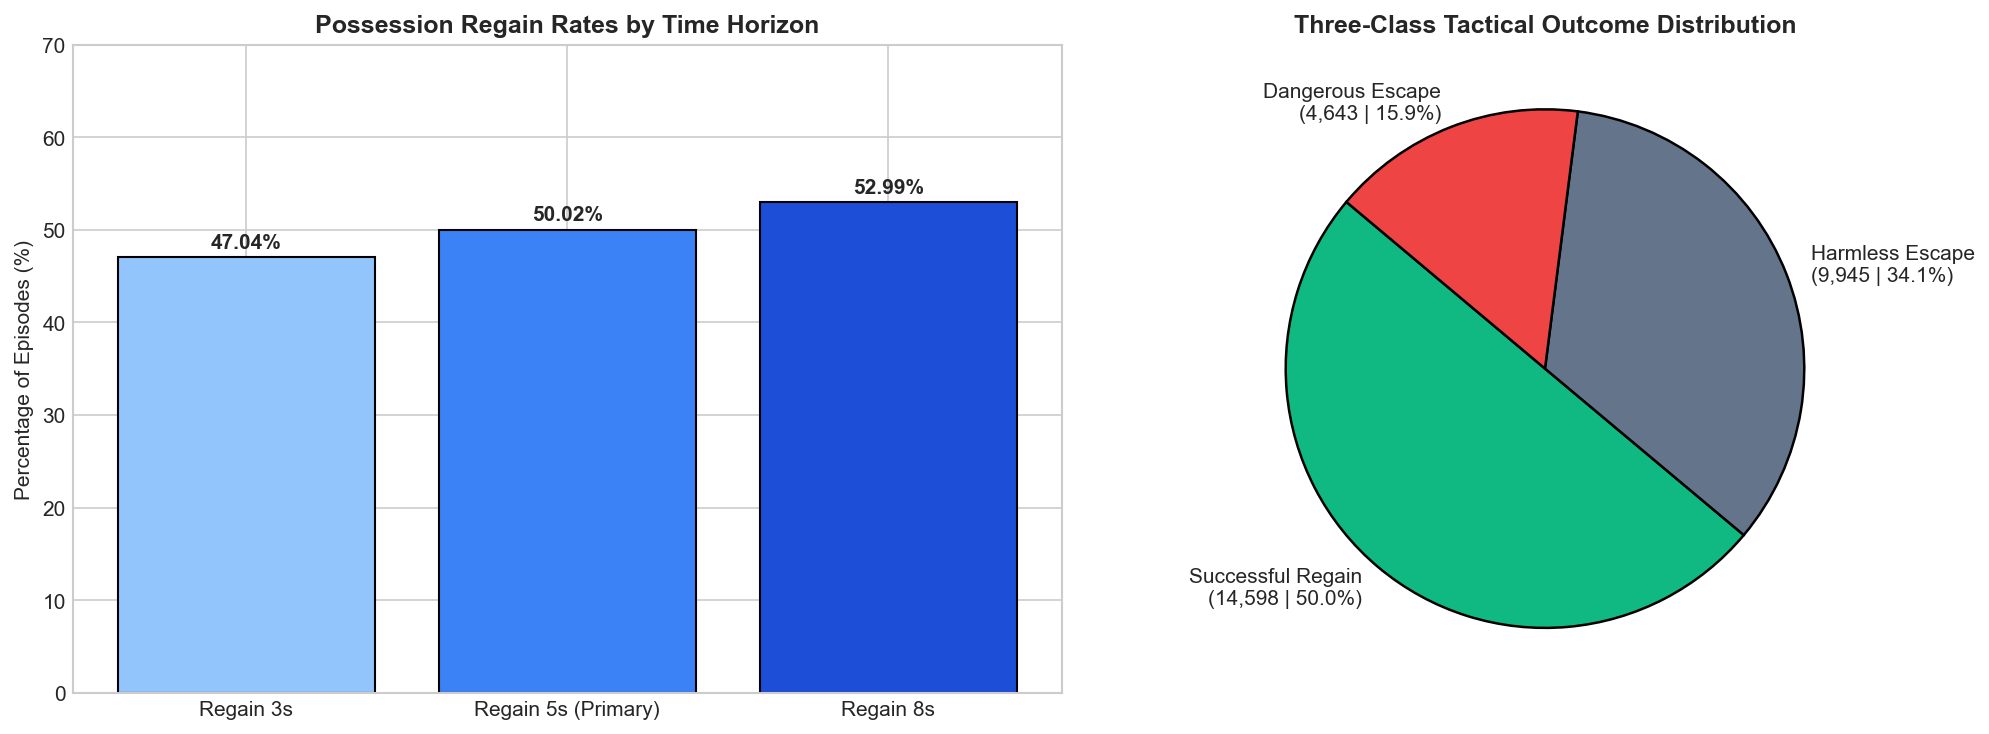

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regain sensitivity
regain_data = {
    "Regain 3s": df_episodes["regain_3s"].mean() * 100,
    "Regain 5s (Primary)": df_episodes["regain_5s"].mean() * 100,
    "Regain 8s": df_episodes["regain_8s"].mean() * 100,
}
axes[0].bar(regain_data.keys(), regain_data.values(), color=["#93c5fd", "#3b82f6", "#1d4ed8"], edgecolor="black")
for idx, (k, v) in enumerate(regain_data.items()):
    axes[0].text(idx, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")
axes[0].set_title("Possession Regain Rates by Time Horizon", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Percentage of Episodes (%)")
axes[0].set_ylim(0, 70)

# Three-class tactical outcome
class_counts = df_episodes["episode_outcome_3class"].value_counts()
colors = ["#10b981", "#64748b", "#ef4444"]
axes[1].pie(
    class_counts.values, 
    labels=[f"{k.replace('_', ' ').title()}\n({v:,} | {v/len(df_episodes)*100:.1f}%)" for k, v in class_counts.items()],
    colors=colors,
    autopct="",
    startangle=140,
    wedgeprops=dict(edgecolor="black", linewidth=1.2),
)
axes[1].set_title("Three-Class Tactical Outcome Distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


## 4. 360 Data Eligibility & Missingness Analysis

We compare counterpress episodes with vs. without usable 360 freeze frames for the initiation event.
*Note: We test whether 360 availability is associated with observable event and match characteristics; Missing-at-Random (MAR) cannot be proven from observational data alone.*


In [6]:
# Parse coordinates
def parse_loc(val):
    if pd.isna(val) or not val: return np.nan, np.nan
    if isinstance(val, str):
        try:
            v = eval(val)
            return float(v[0]), float(v[1])
        except:
            return np.nan, np.nan
    return np.nan, np.nan

coords = df_episodes["initiation_location"].apply(parse_loc)
df_episodes["init_x"] = [c[0] for c in coords]
df_episodes["init_y"] = [c[1] for c in coords]

has_360 = df_episodes[df_episodes["has_initiation_360"]]
no_360 = df_episodes[~df_episodes["has_initiation_360"]]

comp_df = pd.DataFrame([
    {"Metric": "Episode Count", "With 360": f"{len(has_360):,}", "No 360": f"{len(no_360):,}"},
    {"Metric": "Mean Initiation X (units)", "With 360": f"{has_360['init_x'].mean():.2f}", "No 360": f"{no_360['init_x'].mean():.2f}"},
    {"Metric": "Mean Initiation Y (units)", "With 360": f"{has_360['init_y'].mean():.2f}", "No 360": f"{no_360['init_y'].mean():.2f}"},
    {"Metric": "Mean Delay from Turnover", "With 360": f"{has_360['delay_seconds'].mean():.2f}s", "No 360": f"{no_360['delay_seconds'].mean():.2f}s"},
    {"Metric": "Regain 5s Rate", "With 360": f"{has_360['regain_5s'].mean()*100:.2f}%", "No 360": f"{no_360['regain_5s'].mean()*100:.2f}%"},
    {"Metric": "Dangerous Escape 15s Rate", "With 360": f"{has_360['dangerous_escape_15s'].mean()*100:.2f}%", "No 360": f"{no_360['dangerous_escape_15s'].mean()*100:.2f}%"},
])
display(comp_df)


,Metric,With 360,No 360
0,Episode Count,"25,846","3,340"
1,Mean Initiation X (units),65.82,68.57
2,Mean Initiation Y (units),40.40,39.80
3,Mean Delay from Turnover,2.04s,2.11s
4,Regain 5s Rate,49.95%,50.54%
5,Dangerous Escape 15s Rate,16.92%,13.80%


## 5. Sanity Checks & Manual Validation Protocol

We review the automated sanity check results and the stratified 100-episode manual validation sample.


In [7]:
with open(RESULTS_DIR / "tables" / "sanity_checks_report.json") as f:
    sanity = json.load(f)

print("--- Sanity Check Verification ---")
print(f"Duplicate Initiating Events: {sanity['duplicate_initiating_events']} (PASS)")
print(f"Logical Label Contradictions: {sanity['logical_contradictions']} (PASS)")
print(f"Negative Delays: {sanity['negative_delays']} (PASS)")
print(f"Defensive Action != Regain Verified: {sanity['defensive_action_not_regain_verified']} (PASS)")


--- Sanity Check Verification ---
Duplicate Initiating Events: 0 (PASS)
Logical Label Contradictions: 0 (PASS)
Negative Delays: 0 (PASS)
Defensive Action != Regain Verified: True (PASS)


In [8]:
val_df = pd.read_csv(TABLES_DIR / "manual_episode_validation.csv")
print(f"Total Stratified Validation Episodes: {len(val_df)}")
print("Sample Columns:", list(val_df.columns))
display(val_df.head(10))


Total Stratified Validation Episodes: 100
Sample Columns: ['episode_id', 'match_id', 'competition_name', 'period', 'counterpressing_team', 'possession_team', 'initiation_event_type', 'initiation_player_name', 'delay_seconds', 'num_actions', 'algorithm_counterpress_valid', 'human_counterpress_valid', 'algorithm_regain_5s', 'human_regain_5s', 'algorithm_dangerous_escape_15s', 'human_dangerous_escape_15s', 'episode_outcome_3class', 'validation_notes']


,episode_id,match_id,competition_name,period,counterpressing_team,possession_team,initiation_event_type,initiation_player_name,delay_seconds,num_actions,algorithm_counterpress_valid,human_counterpress_valid,algorithm_regain_5s,human_regain_5s,algorithm_dangerous_escape_15s,human_dangerous_escape_15s,episode_outcome_3class,validation_notes
0,3877090_p93_ea7525a6,3877090,Major League Soccer,2,Inter Miami,LAFC,Pressure,Diego Alexander Gómez Amarilla,0.552,1,1,NaN,0,NaN,1,NaN,dangerous_escape,No regain within 5.0s (delay=0.552s). Dangerou...
1,3877170_p13_00347b22,3877170,Major League Soccer,1,Inter Miami,Cincinnati,Pressure,Facundo Farías,0.976,3,1,NaN,0,NaN,0,NaN,harmless_escape,No regain within 5.0s (delay=0.976s). Harmless...
2,3895244_p33_43ad9a28,3895244,1. Bundesliga,1,FC Heidenheim,Bayer Leverkusen,Pressure,Lennard Maloney,1.858,2,1,NaN,0,NaN,1,NaN,dangerous_escape,No regain within 5.0s (delay=1.858s). Dangerou...
3,3857257_p91_d2c41bf1,3857257,FIFA World Cup,1,Australia,Denmark,Pressure,Riley McGree,1.270,1,1,NaN,0,NaN,0,NaN,harmless_escape,No regain within 5.0s (delay=1.27s). Harmless ...
4,3857290_p140_d128b172,3857290,FIFA World Cup,2,Switzerland,Cameroon,Pressure,Ruben Vargas,1.381,1,1,NaN,0,NaN,0,NaN,harmless_escape,No regain within 5.0s (delay=1.381s). Harmless...
5,3893819_p52_866ac308,3893819,Women's World Cup,1,Morocco Women's,Morocco Women's,Duel,Hanane Aït El Haj,0.000,1,1,NaN,1,NaN,0,NaN,successful_regain,Regained possession at dt=0.0s by Morocco Wome...
6,3877060_p106_c43f1586,3877060,Major League Soccer,2,New York Red Bulls,New York Red Bulls,Pressure,Cameron Harper,0.543,2,1,NaN,1,NaN,0,NaN,successful_regain,Regained possession at dt=1.616s by New York R...
7,3837662_p104_c3c8ffb7,3837662,Ligue 1,1,Lille,Paris Saint-Germain,Pressure,Benjamin André,4.925,1,1,NaN,0,NaN,1,NaN,dangerous_escape,No regain within 5.0s (delay=4.925s). Dangerou...
8,3773625_p117_968d0a80,3773625,La Liga,2,Barcelona,Barcelona,Pressure,Sergio Busquets i Burgos,1.048,2,1,NaN,1,NaN,0,NaN,successful_regain,Regained possession at dt=0.869s by Barcelona....
9,3895153_p92_cc974c4e,3895153,1. Bundesliga,2,Bayer Leverkusen,Bayer Leverkusen,Interception,Odilon Kossonou,1.608,1,1,NaN,1,NaN,0,NaN,successful_regain,Regained possession at dt=0.0s by Bayer Leverk...
